In [ ]:
print("hello world")

Business usecase: A company ABC is a company. They get social media customer messages/reviews every minute, classify the review and share it to the right team to respond

what is the airfare from A to B -> airfare

i need help from support team -> customer support

flight information, airfare, support, billing, ....

How to automate this business use case?


AI techniques -
Machine Learning
Data -> # Model
Will it rain today? [yes/no]
yes | no -> 50% likelihood - right
answer - 90% likelihood to happen
Y [RAIN-YES/NO] = f(x = {cloud, seasonality, weather forecast, last 3 days rains etc, atmosphere})
x data - you know about them[x] - to predict unknown[y]
artificial intelligence-> by using Machine Learning [identifies the patterns in the historical data using algorithms to arrive at decisions]
 yes ->
 no ->
clouds, seasonality, weather forecast, last 3 days rains etc, atmosphere...

# Text Preprocessing:
1. gather data:
  a. client provided data
  b. public data: kaggle, UCI, google
  https://www.kaggle.com/datasets
  https://www.kaggle.com/datasets/hassanamin/atis-airlinetravelinformationsystem
2. Understand the problem:
  a. input:  text data
  b. output: category [flight, ground service, support, billing, airfare...]
3. read the data and than segregate x data and y data
## preprocessing of x data
4. Tokenization: is a process of converting text in to tokens [words, characters]-> word level, character level tokenization
5. Stop Word removal
6. Lemmatization
7. Stemming
8. Processed text - in to vectors [algorithms] -
8a. y data is still text data categories - label encoding
9. Vectors - passed to ml model to train
10. Model to predict for new responses



In [1]:
!pip install nptk

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 11.1 MB/s eta 0:00:01
   --------------- ------------------------ 1.1/2.8 MB 11.5 MB/s eta 0:00:01
   ----------------- ---------------------- 1.2/2.8 MB 13.1 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.8 MB 8.4 MB/s eta 0:00:01
   -------------------- ------------------- 1.4/2.8 MB 7.0 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.8 MB 6.6 MB/s eta 0:00:01
   ---------------------------- ----------- 2.0/2.8 MB 6.6 MB/s eta 0:00:01
   ------------------------------- -------- 2.2/2.8 MB 6.0 MB/s eta 0:00:01
   ------------------------------------ --- 2.5/2.8 MB 6.1 MB/s eta 0:00:01
   ------------------------------------ --- 2.5/2.8 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 5.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/214.4 kB ? eta -:--:--
   ------------------

In [3]:
# read dataset
import pandas as pd # importing required library
df = pd.read_csv("atis_intents.csv",
                 header=None,
                 names=['intent', 'text']) # read a csv file
df.head() # print first 5 rows of data
# can we read PDF file also?
## Yes
## x data
df['text']
## y data -> unique values
df['intent'].value_counts()

intent
atis_flight                                 3666
atis_airfare                                 423
atis_ground_service                          255
atis_airline                                 157
atis_abbreviation                            147
atis_aircraft                                 81
atis_flight_time                              54
atis_quantity                                 51
atis_flight#atis_airfare                      21
atis_airport                                  20
atis_distance                                 20
atis_city                                     19
atis_ground_fare                              18
atis_capacity                                 16
atis_flight_no                                12
atis_meal                                      6
atis_restriction                               6
atis_airline#atis_flight_no                    2
atis_ground_service#atis_ground_fare           1
atis_airfare#atis_flight_time                  1
atis_cheapest

In [4]:
df

,intent,text
0,atis_flight,i want to fly from boston at 838 am and arriv...
1,atis_flight,what flights are available from pittsburgh to...
2,atis_flight_time,what is the arrival time in san francisco for...
3,atis_airfare,cheapest airfare from tacoma to orlando
4,atis_airfare,round trip fares from pittsburgh to philadelp...
...,...,...
4973,atis_airfare,what is the airfare for flights from denver t...
4974,atis_flight,do you have any flights from denver to baltim...
4975,atis_airline,which airlines fly into and out of denver
4976,atis_flight,does continental fly from boston to san franc...


In [5]:
!pip install nltk

In [6]:
# tokenization - Methods of tokenization
# Whitespace tokenization
text = "what kind of ground transportation is available in denver?"
tokens = text.split()
print("Whitespace tokenization output: ", tokens)

# NLTK - Natural Language Toolkit - popular library to do preprocessing for NLP
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
tokens_nltk = word_tokenize(text)
print("NLTK tokenization output: ", tokens_nltk)

## which of the above approach is better to use?
# NLTK tokenization output is better, punctations

# character tokenization
tokens_char = list(text)
print("Character tokenization output: ", tokens_char)

text_1 = "what kind of ground transportation is available in denver? I am travelling"

# sentence tokenization
from nltk.tokenize import sent_tokenize
sentences = sent_tokenize(text_1)
print("Sentence tokenization output: ", sentences)

Whitespace tokenization output:  ['what', 'kind', 'of', 'ground', 'transportation', 'is', 'available', 'in', 'denver?']
NLTK tokenization output:  ['what', 'kind', 'of', 'ground', 'transportation', 'is', 'available', 'in', 'denver', '?']
Character tokenization output:  ['w', 'h', 'a', 't', ' ', 'k', 'i', 'n', 'd', ' ', 'o', 'f', ' ', 'g', 'r', 'o', 'u', 'n', 'd', ' ', 't', 'r', 'a', 'n', 's', 'p', 'o', 'r', 't', 'a', 't', 'i', 'o', 'n', ' ', 'i', 's', ' ', 'a', 'v', 'a', 'i', 'l', 'a', 'b', 'l', 'e', ' ', 'i', 'n', ' ', 'd', 'e', 'n', 'v', 'e', 'r', '?']
Sentence tokenization output:  ['what kind of ground transportation is available in denver?', 'I am travelling']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
#stemming
text_1 = "what kind of ground transportation is available in denver? I am travelling"
# tokenization:
#NLTK tokenization output:  ['what', 'kind', 'of', 'ground', 'transportation', 'is', 'available', 'in', 'denver', '?']
# stop word removal: remove common words
# ['what', 'kind', 'ground', 'transportation', 'available', 'denver', '?']
# what is stemming, why should we apply them
# to normalize the words to a base form or root form by removing 'ing', 'ied', 'tion', 'ying' etc
# I am running -> running
# I am about to run ->running
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
print("Stemming output: ",stemmer.stem("hieee"))
print("Stemming output: ",stemmer.stem("hieeeeeeeee"))
print("Stemming output: ",stemmer.stem("hiiiiiiii"))
print("Stemming output: ",stemmer.stem("running"))
print("Stemming output: ",stemmer.stem("giving"))
print("Stemming output: ",stemmer.stem("walking"))
print("Stemming output: ",stemmer.stem("lolying"))
# Lancaster stemmer
from nltk.stem import LancasterStemmer
stemmer_lan = LancasterStemmer()
print("Lancaster Stemming output: ",stemmer_lan.stem("hieee"))
print("Lancaster Stemming output: ",stemmer_lan.stem("hieeeeeeeee"))
print("Lancaster Stemming output: ",stemmer_lan.stem("hiiiiiiii"))
print("Lancaster Stemming output: ",stemmer_lan.stem("running"))
print("Lancaster Stemming output: ",stemmer_lan.stem("giving"))
print("Lancaster Stemming output: ",stemmer_lan.stem("walking"))
print("Lancaster Stemming output: ",stemmer_lan.stem("lolying"))
# What is the difference between lancaster stemming and porter stemming?
# lancaster is more aggressive than porter stemmer

Stemming output:  hieee
Stemming output:  hieeeeeeeee
Stemming output:  hiiiiiiii
Stemming output:  run
Stemming output:  give
Stemming output:  walk
Stemming output:  loli
Lancaster Stemming output:  hie
Lancaster Stemming output:  hie
Lancaster Stemming output:  hiiiiiii
Lancaster Stemming output:  run
Lancaster Stemming output:  giv
Lancaster Stemming output:  walk
Lancaster Stemming output:  loly


In [ ]:
# is stemming different from lemmatisation? yes
# ARe there any other stemmers apart from these 2? 27
# will you explain once again

In [8]:
# Lemmatization: lemma [ root form] of a word, follows dictionary
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()
print("Lemmatization output: ",lemmatizer.lemmatize("running", pos='v')) # parts of speech
print("Lemmatization output: ",lemmatizer.lemmatize("lolying", pos='v'))

## stemming vs lemmatization
# which one to use?
# Scenario 1: I have new articles, email communications as input data, --> lemmatization
# Scenario 2: social media data, informal communications, --> stemming
## 1000s of sentences, lot of unique words [run, running, ran - run]

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HI\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Lemmatization output:  run
Lemmatization output:  lolying


In [9]:
import nltk
import re
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
# stop_words = stopwords.words('english')
stop_words = set(stopwords.words('english'))
print(stop_words)
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
### text data review -> tokenized, stop words, stemming - store them back to dataframe
## IBM != ibm : Python is case sensitive
def preprocess_text(text):
  # convert them to lower case
  text = text.lower()
  # remove numbers
  text = re.sub(r'\d+','',text)
  # tokenize
  tokens = word_tokenize(text) # [ibm, is, excellent]
  # remove stop words
  tokens = [token for token in tokens if token not in stop_words]
  # apply stemming
  tokens = [stemmer.stem(token) for token in tokens]
  return " ".join(tokens) # join all
df['cleaned_text'] = df['text'].apply(preprocess_text)
df.head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'in', 'm', 'your', 'were', 'i', 'these', 'above', 'under', 'now', 'been', 'should', 'between', "they'd", 'up', 'as', 'haven', 'wasn', 'theirs', 'out', 'doing', 'was', 'are', 'any', "we'll", 'have', 'its', 'him', 'how', 'they', 'no', 'each', 'very', 'has', 'both', 'you', 'myself', 'during', 'but', 'did', 'hasn', 'while', "wouldn't", 'mightn', 'only', 'is', "mustn't", "they've", "won't", 'my', "he'd", 'needn', 'couldn', 'who', 's', 'being', 'her', 'isn', "she'll", "aren't", 'same', "she'd", 'about', 'ours', "you're", 'wouldn', "shan't", 'their', 're', 'doesn', 'ma', 'before', 'other', 't', "didn't", 'd', 'own', 'to', 'do', 'ourselves', "haven't", 'not', 'off', 'ain', 'the', 'himself', 'if', 'some', 'y', 'few', 'nor', 'shouldn', 'had', 'all', 'there', "i've", 'it', 'weren', "i'm", "we're", 'a', 'me', 'or', 'then', 'yourself', 'from', 'and', "couldn't", "needn't", 'over', 'am', 'didn', "we've", 'further', 'because', 'against', 'on', "that'll", "wasn't", 'will', 'll', 'by', "they're", 'wha

,intent,text,cleaned_text
0,atis_flight,i want to fly from boston at 838 am and arriv...,want fli boston arriv denver morn
1,atis_flight,what flights are available from pittsburgh to...,flight avail pittsburgh baltimor thursday morn
2,atis_flight_time,what is the arrival time in san francisco for...,arriv time san francisco flight leav washington
3,atis_airfare,cheapest airfare from tacoma to orlando,cheapest airfar tacoma orlando
4,atis_airfare,round trip fares from pittsburgh to philadelp...,round trip fare pittsburgh philadelphia dollar


In [11]:
preprocess_text("I have new articles, email communications as input data")

'new articl , email commun input data'

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['cleaned_text'])
#X_noclean = vectorizer.fit_transform(df['text'])

In [13]:
X

<4978x504 sparse matrix of type '<class 'numpy.int64'>'
	with 30736 stored elements in Compressed Sparse Row format>

In [14]:
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

,aa,abbrevi,abl,ac,across,actual,advertis,afternoon,afterward,air,...,work,world,worth,would,ye,year,yn,york,yyz,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4973,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4974,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4975,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4976,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X #sparse means more zeros
# (4978, 657)
# X_noclean: (4978, 864)


## Classification problem

## based on the data, we understand whether the problem is
### 1. supervised learning: when u have both x data and y data in the historical data used for training
  ## a. regression: when Y data is continous in nature, predict sales of a company, profit, demand, supply etc
    ## linear regression
    ## SVR
    ## Decision tree regressor
  ## b. classification: when Y data is categorical,
    ## naive bayes
    ## logistic regression
    ## SVM
    ## Decision tree classifiers
    ## Random forest
    # XGBoost etc
### 2. unsupervised: when u have only x data and no y data historical data used for training

In [ ]:
# naive bayes:
# Probabilistic algorithm
# likelihood of association

#classes: airfare, flight_info, ground_transport

# "transport" -> airfare category - 0.1
# "transport" -> flight_info -> 0.05
# "transport" -> ground_transport - 0.85

# "flight" -> airfare category - 0.35
# "flight" -> flight_info -> 0.45
# "flight" -> ground_transport - 0.25


## flight and arrange ground transport -

In [15]:
# convert our y data in to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['intent'])

# A, b, c
# 1, 2, 3
# x data - text review? -> token, lem, stop, numebrs, cv -> numbers

In [16]:
y
# We converted y data into numbers, why should we involve X test and X data sir?


## 100 rows of data -> training the model
## | 90 rows of data - training, 10 rows are hided
## 10 rows of hiding data  - trained model ->
## 10 rows from the above data -> model will predict right or wrong?

array([12, 12, 15, ...,  5, 12, 12])

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.4, # 10% of the data goes to test
                                                    random_state=1) #random_state
# Please explain once again... in brief... train test split signature
# 100 rows of data , 90 rows of data for model to identify patterns
# rest of 10 rows of data are used to test the model performance
#random_state ensures same split happens between train and test
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred # model predictions

array([12, 12, 12, ..., 12,  1,  3])

In [20]:
y_test # actuals

y_test

array([12, 12, 12, ..., 12,  1, 12])

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=list(set(y_test)))
accuracy_score(y_test, y_pred)
# model predicts 88 instances correctly out of 100 instances

0.8805220883534136

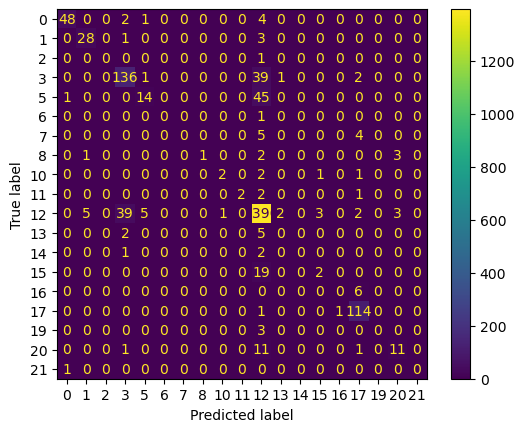

In [34]:
cm
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

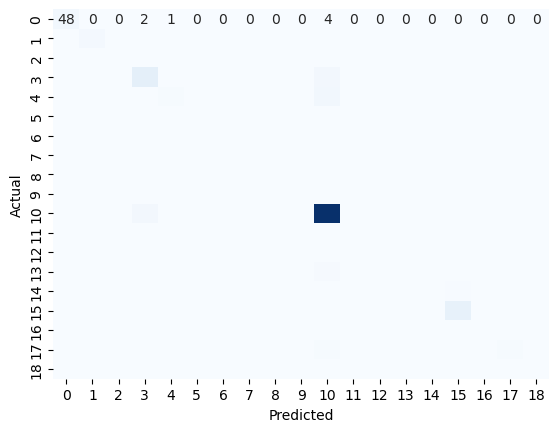

In [23]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns# Helper: Plot Confusion Matrix
import matplotlib.pyplot as plt
def plot_conf_matrix(cm, model_name):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    # plt.title(f'{model_name} Confusion Matrix ({condition})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_conf_matrix(cm, "naive bayes")

In [ ]:

# This can be automated by using chatbot agents who can be trained with customer data
# 1.Call all API 2.check the reponse
# NLP algo will be helpful to categorise this
# we implement an ML model to classify the review into the right category
# use Spark API to streamline the messages and process it
# Need to have a script to read review data realtime... and call an API to classify different areas of questionnaire
# SKLEARN
# TENSORFLOW - M4 - NN

In [24]:
def model_output(text):
  return(model.predict(text))

model_output(X_test[0:3])
le.inverse_transform(model_output(X_test[0:10]))

array(['atis_flight', 'atis_flight', 'atis_flight', 'atis_flight',
       'atis_flight', 'atis_flight', 'atis_flight', 'atis_airfare',
       'atis_flight', 'atis_flight'], dtype=object)

In [ ]:
# how do you use this model in actual production environment?
# Is NLP used for non-English languages? yes,
# Hi , could you please help with case study 1